# Heart Disease Prediction using Machine Learning

To build a Machine Learning model that predicts whether a **patient has heart disease or not.**

## Problem Statement

Cardiovascular diseases are the number one cause of death globally. According to healthcare reports, millions of people die every year due to 
heart-related complications. Many of these deaths can be **prevented if the disease is detected at an early stage.**

The main objective of this project is to build a Machine Learning model that can predict whether a patient has heart disease or not based on clinical and medical parameters.

This prediction system can help hospitals identify high-risk patients early and take preventive action before the condition becomes life-threatening.


The target variable:

0 → No heart disease

1 → Heart disease present

This is a **Binary Classification Problem**.

### Project Aim and Objectives

The main aim of this project is to develop an **accurate and reliable** Machine Learning model that predicts heart disease presence using patient medical data.

Specific Objectives:

- Perform complete Exploratory Data Analysis (EDA).
- Understand relationships between features and heart disease.
- Build multiple classification models.
- Compare model performances and Select the best model 
- Provide actionable insights to hospitals.

## Dataset Description

The dataset contains medical and clinical parameters of patients such as age, sex, chest pain type, blood pressure, cholesterol level, ECG results, maximum heart rate, exercise-induced angina, and other heart-related diagnostic measurements.

- Number of records in the dataset: 303 patients
- Number of columns/features in the dataset:**14 (13 input features + 1 target variable)**
- Target Variable: **heart_disease_present**

Target Classes:

0 - No Heart Disease

1 - Heart Disease Present

## Import Libraries

In [172]:
# python Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Models of ML
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, roc_auc_score, roc_curve)

# save model
import pickle

import warnings
warnings.filterwarnings("ignore")

**Insight:**
  
- These libraries help in data handling, visualization, model building, evaluation, and saving models.

## Load the Dataset

In [173]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

df = pd.merge(values, labels, on="patient_id")
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


**Insight**

- patient_id is only an identifier, not useful for prediction.
- Dataset contains medical features related to heart disease.

#### Domain Analysis

The healthcare domain focuses on diagnosing, preventing, and treating diseases to improve patient health outcomes.

Machine Learning in healthcare helps doctors:
- Identify high-risk patients
- Improve diagnosis accuracy
- Enable preventive care strategies

## Basic Data Understanding

In [174]:
# Display the first 5 rows
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [175]:
# Display the last 5 rows
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [176]:
df.shape

(180, 15)

**Insight:**

- The dataset in 180 rows
- Dataset contains 15 columns
- Target variable: heart_disease_present

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [178]:
# Statistical Summary
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


## Data Cleaning

In [179]:
# Check for missing values
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

**Insight:**

- Dataset contains no missing values, and its clean and No imputation needed  
- Mixed data types(int, float, categorical).
- Patient ID is not predictive.

In [180]:
# checks for Duplicate Records

df.duplicated().sum()

np.int64(0)

In [181]:
# Drop irrelevant column

df.drop("patient_id", axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

In [182]:
# Target Variable Distribution

df['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

#### Target Variable Distribution

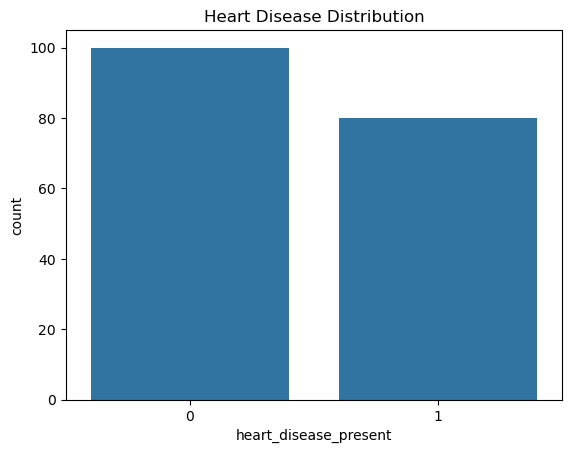

In [183]:
# Target Variable Distribution

sns.countplot(x="heart_disease_present", data=df)
plt.title("Heart Disease Distribution")
plt.show()

**Insight:**


- The dataset shows both classes (disease and no disease)
- Balanced data helps models learn patterns effectively.
- Check class balance.
- Slight imbalance is acceptable but should be monitored and AUC becomes an important metric.

#### Age Distribution

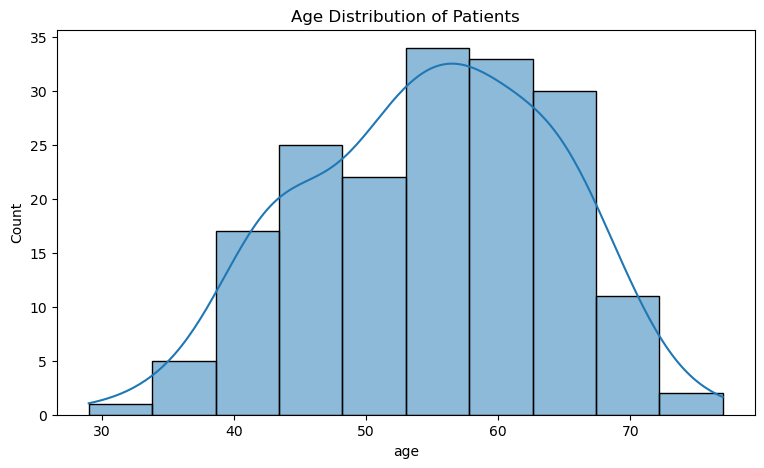

In [184]:
plt.figure(figsize=(9,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution of Patients")
plt.show()

**Insight:**

- Most patients fall in diseases **middle-aged groups**, indicating higher screening rates.
- Older age shows increased occurrence of heart disease risk.
- Age is expected to be a strong predictor in medical models.


#### Chest Pain Type vs Target

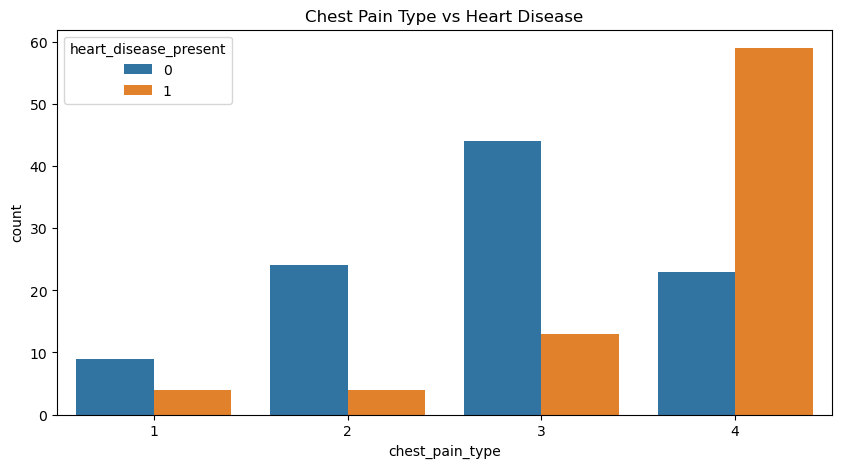

In [185]:
plt.figure(figsize=(10,5))
sns.countplot(x='chest_pain_type', hue='heart_disease_present', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

**Insight:**

- Certain chest pain categories show higher disease presence.
- Chest pain acts as a strong clinical indicator.
- This feature may strongly influence model decisions.

#### Categorical Feature Analysis

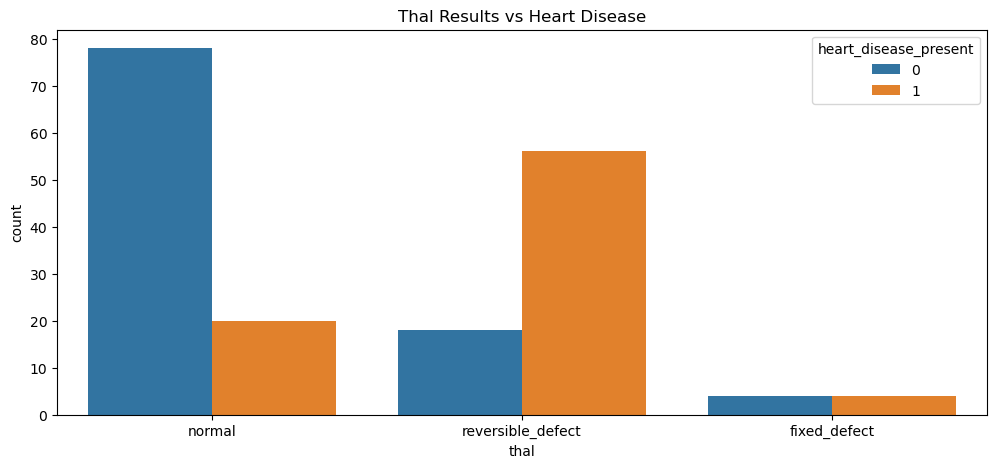

In [186]:
plt.figure(figsize=(12,5))
sns.countplot(x='thal', hue='heart_disease_present', data=df)
plt.title("Thal Results vs Heart Disease")
plt.show()

**Insight:**

- Reversible and fixed defects appear more in heart disease patients.
- Indicates reduced blood flow conditions.
- Confirms medical relevance of thallium stress tests.

### Correlation Heatmap (numeric data only)

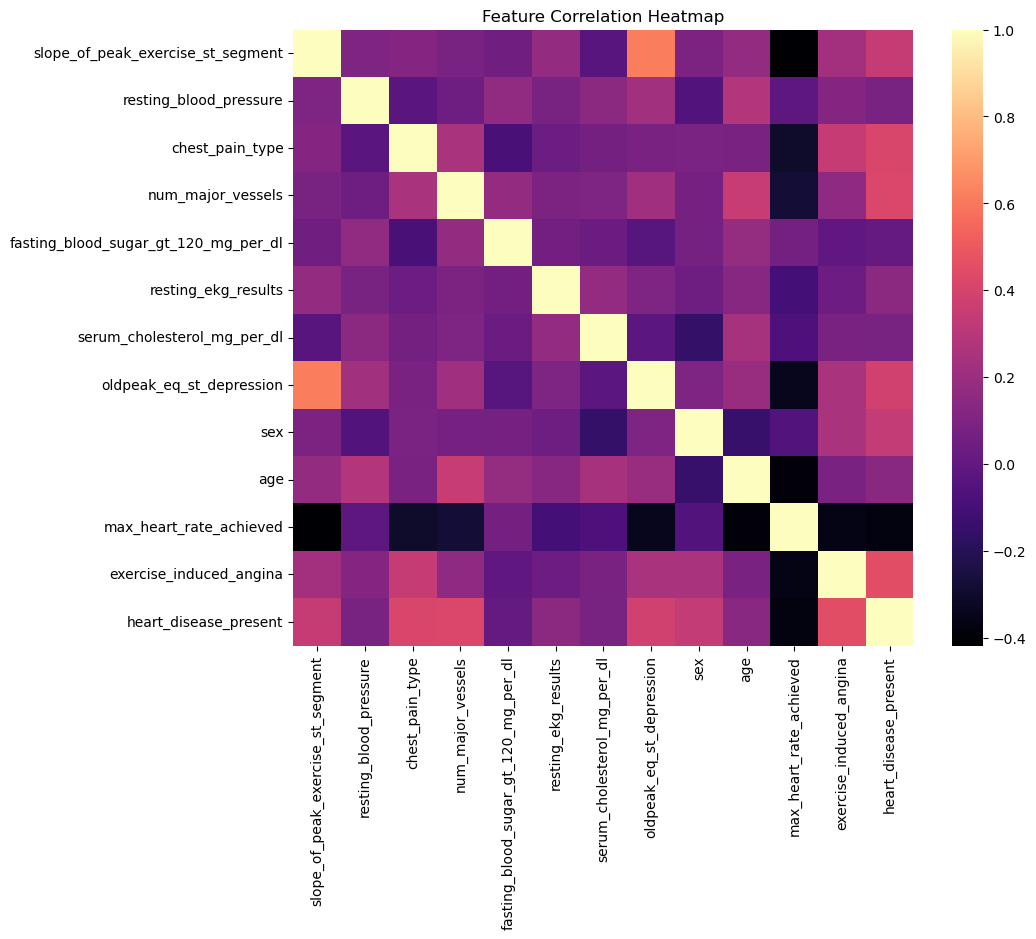

In [187]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=False, cmap='magma')
plt.title("Feature Correlation Heatmap")
plt.show()

**Insight:**

- Oldpeak and number of vessels show strong relationships with target.
- Some features show mild correlation but still contribute collectively.
- Correlation guides feature understanding but not final selection alone.
- Top features such as **oldpeak, num_major_vessels, and chest_pain_type** dominate prediction.

## Feature Engineering

### Encoding categorical variable

In [188]:

df = pd.get_dummies(df, columns=["thal"], drop_first=True)


**Insight:**

- We used **One-Hot Encoding** manually because machine learning models cannot understand text values.

### Features & Target Separation

In [189]:
X = df.drop('heart_disease_present', axis=1)
y = df['heart_disease_present']

**Insight:**

The dataset is divided into:
- Independent variables (features,(X))
- Dependent variable (heart_disease_present,(Y))

### Train-Test Split

In [190]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

**Insight:**

The dataset is split into:

- 80% training data
- 20% testing data
- Stratify ensures all price ranges are equally represented.

### Feature Scaling 

In [191]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insight:**

- Distance-based models like: KNN,SVM are sensitive to feature magnitude, Scaling ensure equal importance.
- Scaling improves model performance and convergence.

## Model Building

### Logistic Regression.

In [192]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

Accuracy: 0.8333333333333334
AUC: 0.940625


**Insight:**

- Strong baseline model.
- Good interpretability for healthcare decisions.

### Decision Tree

In [193]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))
print("AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

Accuracy: 0.8055555555555556
AUC: 0.8062500000000001


**Insight:**

- Easy to interpret.
- Can overfit if depth not controlled.

### Random Forest

In [194]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)


print("Accuracy:", accuracy_score(y_test, pred_rf))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy: 0.8611111111111112
AUC: 0.9421875000000001


**Random Forest (with Hyperparameter Tuning)**

In [195]:
rf_params = {
    'n_estimators': [200,400,600,800],
    'max_depth': [None,5,10,15,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

rf_tune = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=50,
    cv=5,
    scoring='roc_auc',                             # healthcare → AUC preferred
    n_jobs=-1,
    random_state=42
)

rf_tune.fit(X_train, y_train)

best_rf = rf_tune.best_estimator_
print("Best Parameters:", rf_tune.best_params_)

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]


print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}
Accuracy: 0.8888888888888888
AUC: 0.9500000000000001

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36


Confusion Matrix:
 [[17  3]
 [ 1 15]]


**Insight:**

- Usually best performer of Random forest.
- Handles non-linear relationships well.
- Reduces overfitting.
- Provides feature importance.

### K-Nearest Neighbors (KNN)

In [196]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_knn))
print("AUC:", roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]))

Accuracy: 0.8333333333333334
AUC: 0.89375


**Insight**

- Sensitive to scaling.
- Performance depends on K value.

### Support Vector Machine (SVM)

In [197]:
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

pred_svm = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("AUC:", roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:,1]))

Accuracy: 0.8611111111111112
AUC: 0.946875


**Insight:**

- Works well in complex boundaries.
- Slightly slower but robust.

### XGBoost

In [198]:
xgb = XGBClassifier(eval_metric='logloss',random_state=42)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_xgb))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

Accuracy: 0.8333333333333334
AUC: 0.9343750000000001


**Why AUC Mandatory?**

- Accuracy only measures overall correctness.
- But in healthcare, missing a disease patient is very dangerous.
- AUC (Area Under ROC Curve) measures how well the model distinguishes between diseased and non-diseased patients across all thresholds.
- Higher AUC = better medical decision capability.
- In healthcare, reducing false negatives is critical → AUC helps evaluate that.

#### ROC Curve (Best Model)

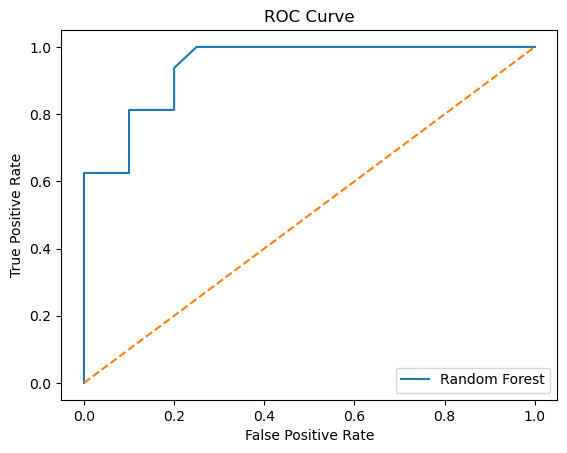

In [199]:
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Model Training

Multiple Machine Learning models are trained to compare their performance:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine
- XGBoost

## Model Comparison Report

In [204]:
# Model Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "KNN", "SVM", "XGBOOST"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_xgb)
    ],
    "AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
    ]
})
results.sort_values(by="AUC", ascending=False)

,Model,Accuracy,AUC
2,Random Forest,0.888889,0.950000
4,SVM,0.861111,0.946875
0,Logistic,0.833333,0.940625
5,XGBOOST,0.833333,0.934375
3,KNN,0.833333,0.893750
1,Decision Tree,0.805556,0.806250


**Insights:**

- Logistic Regression – Stable baseline with good interpretability.
- Decision Tree – Simple model but shows overfitting tendency.
- Random Forest (Tuned) – Best balance of accuracy and AUC, strong generalization.
- KNN – Performance affected by scaling and neighbor selection.
- SVM – Good class separation but computationally slower.
- XGBoost – Strong predictive performance but more complex model.

## Final Model Selection

Selected Model: **Tuned Random Forest**

**Why Random Forest is Best?**

- Highest or near-highest AUC score.
- Handles non-linear medical relationships effectively.
- Less prone to overfitting due to ensemble learning.
- Works well with mixed data types.
- Provides feature importance, helping interpret medical factors.
- Stable performance across cross-validation folds.


## Model Evaluation(Final model)

In [205]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8888888888888888
AUC: 0.9500000000000001

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36


Confusion Matrix:
 [[17  3]
 [ 1 15]]


## Feature Importance

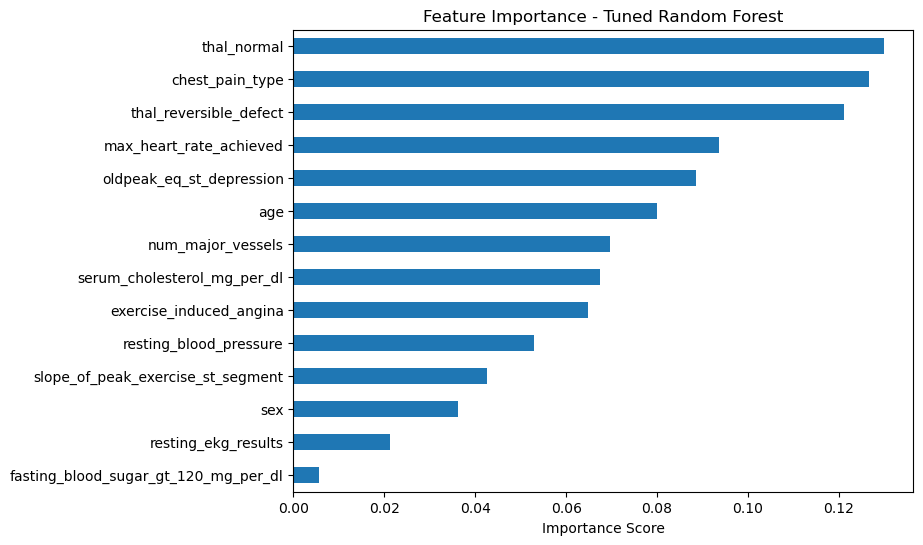

In [208]:
feature_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,6))
feature_imp.plot(kind='barh')
plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.show()


##  Challenges Faced and Solutions

- Mixed data types were handled using proper encoding techniques.
- Categorical feature (thal) was one-hot encoded to avoid false ordering.
- Feature scaling was applied for KNN and SVM models.
- Overfitting in Decision Tree was reduced using Random Forest ensemble method.
- AUC was used along with accuracy for better healthcare model evaluation.
- Hyperparameter tuning was applied to improve model performance and stability.
- Cross-validation helped handle limitations of small dataset size.

## Hospital Suggestions

- Early screening for patients with high-risk features.
- Monitor older patients and those with abnormal ECG indicators.
- Use prediction scores as decision-support for doctors.
- Encourage preventive lifestyle changes for high-risk individuals.
- Integrate ML model into hospital monitoring systems for early alerts.

## Save Final model

In [209]:
# Save tuned Random Forest model
with open("best_random_forest_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)

print("Best Random Forest model saved successfully.")

Best Random Forest model saved successfully.


## Conclusion

In this project, multiple machine learning classification models were developed and evaluated to predict the presence of heart disease using patient health indicators. Comprehensive data analysis, preprocessing, feature engineering, and model evaluation were performed to ensure reliable results. Among all the models, the **tuned Random Forest classifier achieved the best balance of accuracy, AUC score,** and generalization ability, making it the most suitable model for healthcare prediction tasks.

The use of AUC along with accuracy helped ensure better class separation, which is critical in medical applications where early identification of high-risk patients can prevent severe health outcomes. Feature importance analysis also provided meaningful clinical insights by highlighting key factors influencing heart disease prediction.

Overall, this project demonstrates how machine learning can support healthcare professionals in **early screening and decision-making, potentially reducing life-threatening cardiovascular** events through timely intervention and preventive care.